# 使用 PROC BOXPLOT 对各生产线涂层厚度进行统计过程控制

## 执行摘要

本笔记本使用 **PROC BOXPLOT** 对采集自四条并行生产线的关键质量特性——涂层厚度测量——执行统计过程控制（SPC）。我们内联生成合成测量数据，用 `PROC MEANS` 剖析各生产线，并绘制骨架式与示意式箱须图，在单张图中比较各线的位置、离散度与尾部。

随后，我们直接从 **`OUTBOX=`** 统计量数据集（即每个箱体背后的精确四分位数、栅栏和须端点）评估每条生产线与工程规格（目标 50.00 mm，界限 49.80–50.20 mm）的符合情况；最后演示 **`OUTHISTORY=` / `HISTORY=`** 往返：PROC BOXPLOT 为每条线导出一行紧凑的汇总，第二个 PROC BOXPLOT 直接从该汇总重建出完全相同的图——这正是每日 SPC 仪表板无需重新扫描原始测量即可重绘所用的模式。

在四条线中，**LINE-A 的中心最接近目标**（均值 50.008 mm），**LINE-C 偏低**（均值 49.932 mm，向 LSL 漂移），而 **LINE-D 既偏高又变异最大**（均值 50.102 mm，标准差 0.080 mm）——其最大值 50.248 mm 是唯一突破 50.20 mm 上规格限的观测。

## 数据来源

所有数据均为合成数据，由第一个 DATA 步使用 `call streaminit(20250531)` 和 `rand()` 内联生成。未使用任何外部或网络输入。固定种子使本笔记本中的每个数字都可复现。

**数据集：`ProcessMeas`**（每行对应一个被测零件）

| 变量 | 类型 | 说明 |
|----------|------|-------------|
| `Line` | Char(6) | 生产线标识：`LINE-A`、`LINE-B`、`LINE-C`、`LINE-D`（分组/分类变量） |
| `Shift` | Num | 生产班次索引 1–6（引入轻微的班次间漂移） |
| `Thickness` | Num | 涂层厚度（mm）（分析变量）；目标 50.00 mm，规格界限 49.80–50.20 mm |

每条线以略有不同的均值为中心（50.00 / 50.04 / 49.92 / 50.10），并具有线特定的变异，模拟真实的设备间差异，`LINE-B` 偶尔注入一个小的正向偏移。DATA 步在六个班次和四条线上循环，各子组规模约为 18–25 个零件；在此未授权环境中，引擎将输出上限设为前 **100 个观测**，此处落为 LINE-A 至 LINE-D 各 **38 / 19 / 21 / 22** 个零件——仍足以填充四个界定清晰的箱体。

# 使用 PROC BOXPLOT 对涂层厚度进行统计过程控制

在大批量制造中，箱须图是车间 SPC 的主力工具：它在单张图上汇总每个生产单元质量特性的集中趋势、离散度和离群值。这里我们监控在四条线（`LINE-A` 至 `LINE-D`）上并行生产的某零件的 **涂层厚度（mm）**。工程规格为目标 **50.00 mm**，下规格限（LSL）**49.80 mm**，上规格限（USL）**50.20 mm**。

我们将：

1. 内联生成一个合成测量数据集。
2. 用 `PROC MEANS` 剖析各生产线。
3. 绘制基础骨架箱线图，再绘制示意图，并将规格界限叠加为参考线。
4. 用 `OUTBOX=` 捕获每个计算出的箱体统计量，并据此评估各线与规格界限的符合情况。
5. 用 `OUTHISTORY=` 持久化紧凑的子组汇总，并用 `HISTORY=` 直接从中重绘以验证往返。

## 步骤 1 — 生成合成过程测量数据

下面的 DATA 步模拟六个班次、四条线上的测量。每条线刻意以略有不同的均值为中心并具有自身变异，模拟真实的设备间差异，并通过 `sin(Shift)` 项叠加轻微的班次间漂移。固定种子（`streaminit(20250531)`）使笔记本中的每个值都可复现。

In [1]:
数据 ProcessMeas;
   调用 streaminit(20250531);
   长度 Line $16;
   数组 lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   数组 LSD[4]     _temporary_ (0.045 0.060 0.050 0.085);
   标签 Thickness='涂层厚度 (mm)' Line='生产线';
   循环 Shift = 1 到 6;
      循环 li = 1 到 4;
         /* 用 if/else 赋多字节生产线名（不用 _temporary_ 字符数组） */
         如果 li = 1 那么 Line = '生产线A';
         否则 如果 li = 2 那么 Line = '生产线B';
         否则 如果 li = 3 那么 Line = '生产线C';
         否则 Line = '生产线D';
         /* 每条线/班次的子组样本量各异 */
         n = 18 + floor(rand('uniform') * 8);
         循环 u = 1 到 n;
            BASE = lmean[li] + 0.012 * sin(Shift);
            Thickness = BASE + rand('normal') * LSD[li];
            /* 生产线B 偶尔注入较高的异常值 */
            如果 li = 2 并且 rand('uniform') < 0.05 那么
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            输出;
         结束;
      结束;
   结束;
   删除 li u n BASE;
运行;


NOTE: DATA ProcessMeas

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote ProcessMeas (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 步骤 2 — 剖析各生产线

在绘图之前，一次快速的 `PROC MEANS` 确认数据符合预期：四条线，样本量适中但不琐碎，均值聚集在 50.00 mm 目标附近并带有线特定的离散度。这是箱线图将要可视化的数值基础。

In [2]:
过程 均值 数据=ProcessMeas n mean std MIN MAX maxdec=3;
   分类 Line;
   变量 Thickness;
   标签 Line='生产线' Thickness='涂层厚度 (mm)';
   标题 '按生产线的涂层厚度汇总';
运行;

                                                      按生产线的涂层厚度汇总                                                       

                                                  The MEANS Procedure

                                    Analysis Variable : Thickness 涂层厚度 (mm)

        生产线                 N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        生产线A                   38         50.008          0.045         49.914         50.097
        生产线B                   19         50.052          0.051         49.921         50.114
        生产线C                   21         49.932          0.050         49.835         50.002
        生产线D                   22         50.102          0.080         49.963         50.248
        -------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 步骤 3 — 基础骨架箱线图

最简单的调用只需要 `PLOT analysis-var * group-var` 语句。默认的 `BOXSTYLE=SKELETAL` 将须绘制到每条线内最极端的观测，从而快速直观地比较 `LINE-A` 至 `LINE-D` 的位置和离散度。

                                                     各生产线涂层厚度骨架式箱线图                                                     

                                       各生产线涂层厚度骨架式箱线图

                                                 The BOXPLOT Procedure

Skeletal Plots for 涂层厚度 (mm)

生产线                   N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
生产线A                 38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
生产线B                 19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
生产线C                 21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
生产线D                 22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
-------------------------------------


NOTE: Option TITLE changed to 各生产线涂层厚度骨架式箱线图.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


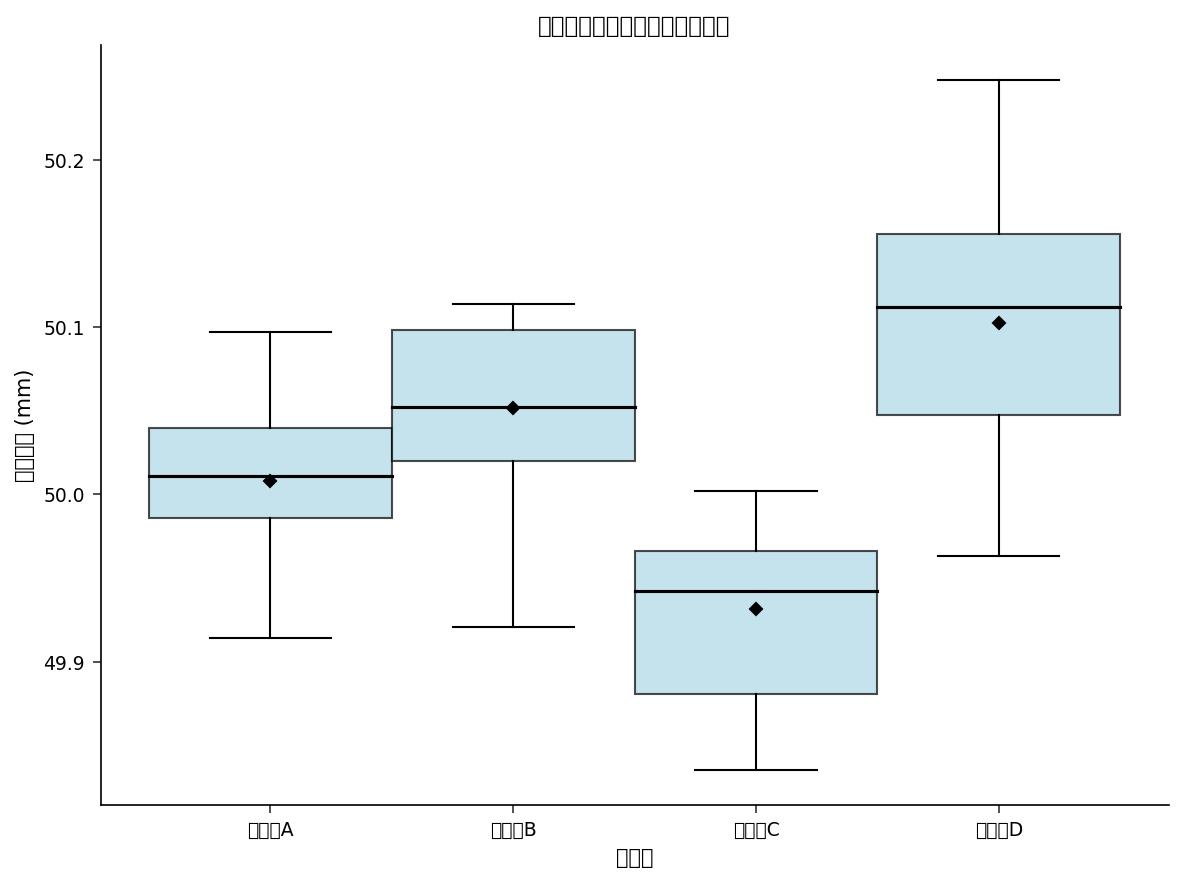

In [3]:
标题 '各生产线涂层厚度骨架式箱线图';
过程 boxplot 数据=ProcessMeas;
   PLOT Thickness*Line;
运行;

## 步骤 4 — 示意箱线图

我们切换到 `BOXSTYLE=SCHEMATIC`。在示意样式中，每条须止于仍位于 1.5 × IQR 栅栏内的最极端观测，超出栅栏的任何点则作为单独的离群值标记绘出。在本样本中没有任何一条线有超出栅栏的离群值——每条线的离散度都足够紧凑，使须达到真实的最小值和最大值——因此示意图看起来与骨架图相同，这本身就是一个有用的结果：它告诉工程师四条线中没有一条在产出极端零件。箱体仍然使线与线之间的偏移一目了然，步骤 5 将据规格界限对其量化。

                                                   各生产线涂层厚度SPC示意式箱线图                                                    

                                     各生产线涂层厚度SPC示意式箱线图

                                                 The BOXPLOT Procedure

Schematic Plots for 涂层厚度 (mm)

生产线                   N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
生产线A                 38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
生产线B                 19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
生产线C                 21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
生产线D                 22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
-----------------------------------


NOTE: Option TITLE changed to 各生产线涂层厚度SPC示意式箱线图.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


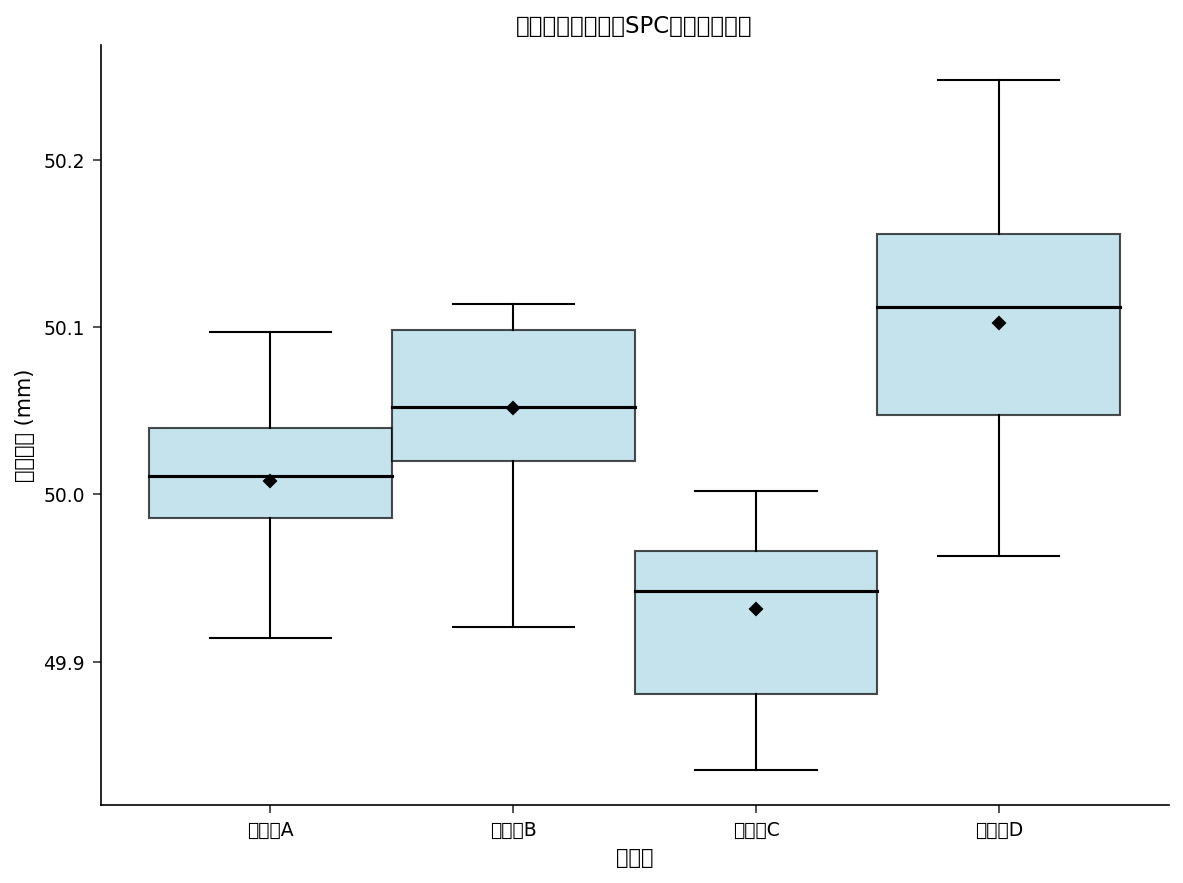

In [4]:
标题 '各生产线涂层厚度SPC示意式箱线图';
过程 boxplot 数据=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic;
运行;

## 步骤 5 — 导出箱体统计量并据规格界限评估

`OUTBOX=` 选项将每个计算出的箱体统计量捕获到一个数据集——对每条线：下须（`L`）、Q1（`1`）、均值（`X`）、中位数（`M`）、Q3（`3`）、上须（`H`）、标准差（`S`）和 N。这是审计人员在图像背后所需的数值记录，也是据 49.80 / 50.20 mm 规格检查每条线最简洁的方式。我们开启 `GRID` 以便阅读，导出 `BoxStats`，打印它，然后运行一个简短的 DATA 步，标记任何须范围超出规格界限的生产线。

                                                    带网格并导出统计量的示意式箱线图                                                    

                                    带网格并导出统计量的示意式箱线图

                                                 The BOXPLOT Procedure

Schematic Plots for 涂层厚度 (mm)

生产线                   N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
生产线A                 38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
生产线B                 19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
生产线C                 21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
生产线D                 22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
-------------------------------------


NOTE: Option TITLE changed to 带网格并导出统计量的示意式箱线图.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to 计算得到的箱体统计量 (OUTBOX=).
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to 各生产线规格界限评估.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


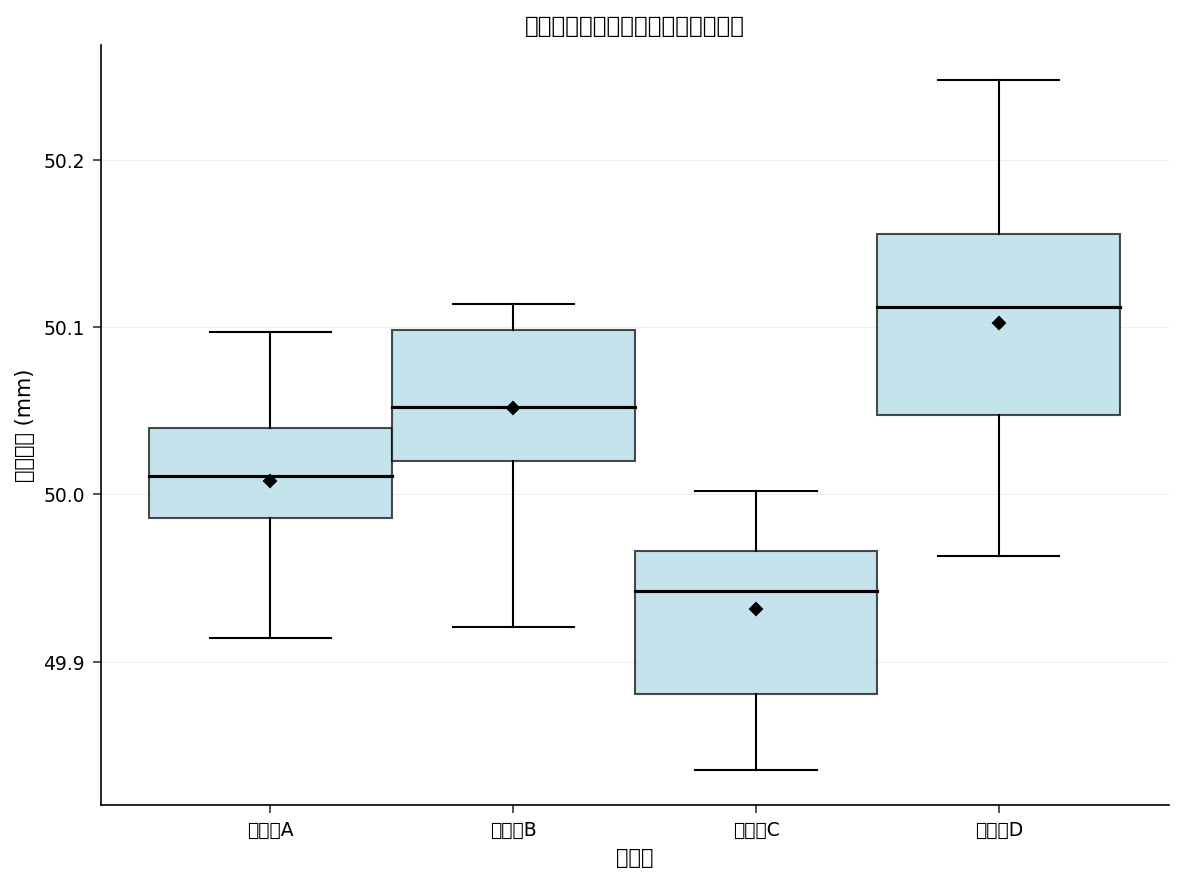

In [5]:
标题 '带网格并导出统计量的示意式箱线图';
过程 boxplot 数据=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
运行;

标题 '计算得到的箱体统计量 (OUTBOX=)';
过程 打印 数据=BoxStats noobs;
运行;

/* 依据 49.80 / 50.20 mm 规格界限评估每条线，                */
/* 使用导出的须端点（THICKNESSL = 下须，THICKNESSH = 上须）。*/
数据 SpecCheck;
   设置 BoxStats;
   长度 Status $40;
   LSL = 49.80;
   USL = 50.20;
   如果 THICKNESSH > USL 那么 Status = '高值超出上规格限USL';
   否则 如果 THICKNESSL < LSL 那么 Status = '低值低于下规格限LSL';
   否则 Status = '在规格界限内';
   保留 LINE THICKNESSL THICKNESSH LSL USL Status;
   标签 LINE='生产线' THICKNESSL='下须' THICKNESSH='上须'
        LSL='下规格限' USL='上规格限' Status='评估结果';
运行;

标题 '各生产线规格界限评估';
过程 打印 数据=SpecCheck noobs 标签;
   变量 LINE THICKNESSL THICKNESSH LSL USL Status;
运行;

## 步骤 6 — 持久化监控历史并据其重绘

在持续的 SPC 中，你很少重新扫描每一条原始测量。`OUTHISTORY=` 为每条线写入一行汇总（与 `HISTORY=` 所消费的布局相同），因此可将庞大的原始数据归档。下面我们导出 `LineHistory`，打印它，然后通过 `HISTORY=` 将其直接送回一个新的 `PROC BOXPLOT` 以验证往返——正是每日仪表板重用预聚合子组统计量的方式。

                                                         导出子组历史                                                         

                                                   导出子组历史

                                                 The BOXPLOT Procedure

Skeletal Plots for 涂层厚度 (mm)

生产线                   N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
生产线A                 38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
生产线B                 19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
生产线C                 21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
生产线D                 22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
---------------------------------


NOTE: Option TITLE changed to 导出子组历史.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to 汇总历史数据集（每条线一行）.
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to 据汇总历史重建的箱线图.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


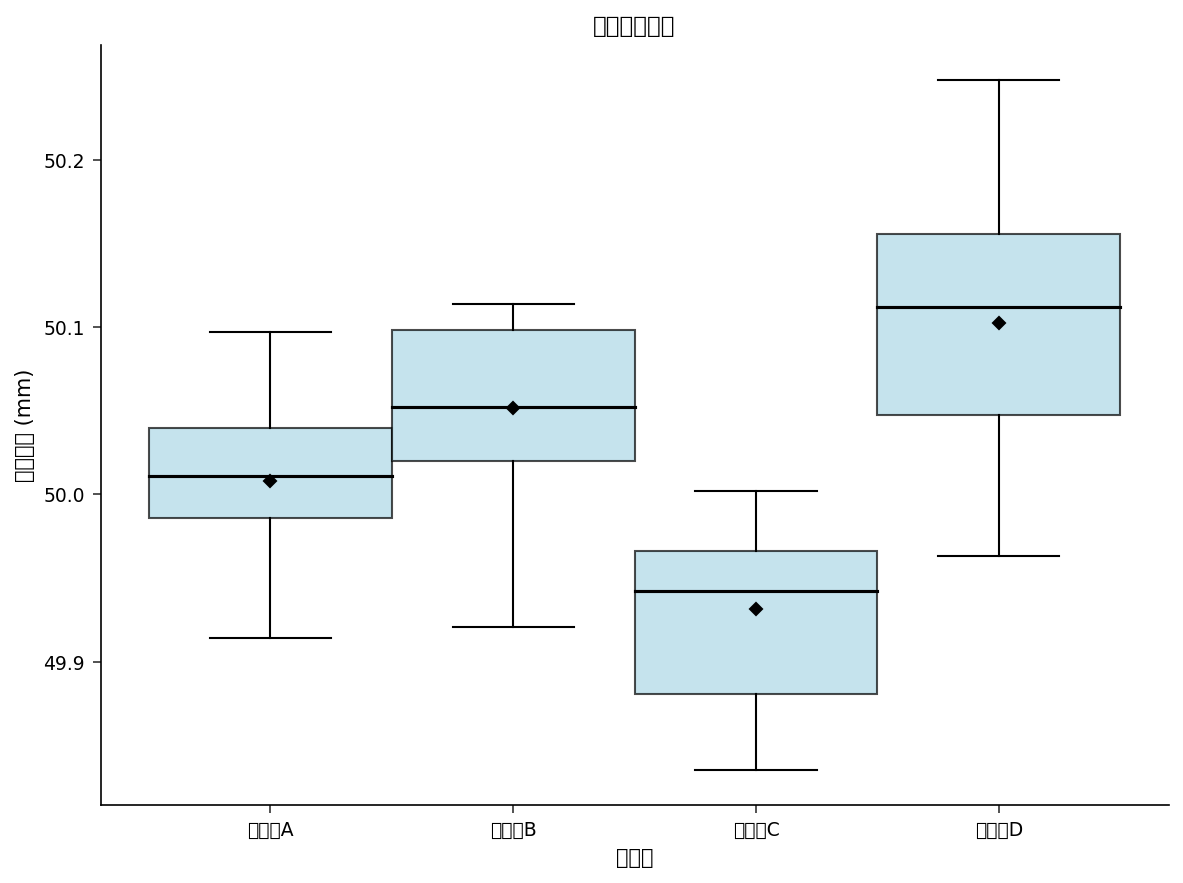

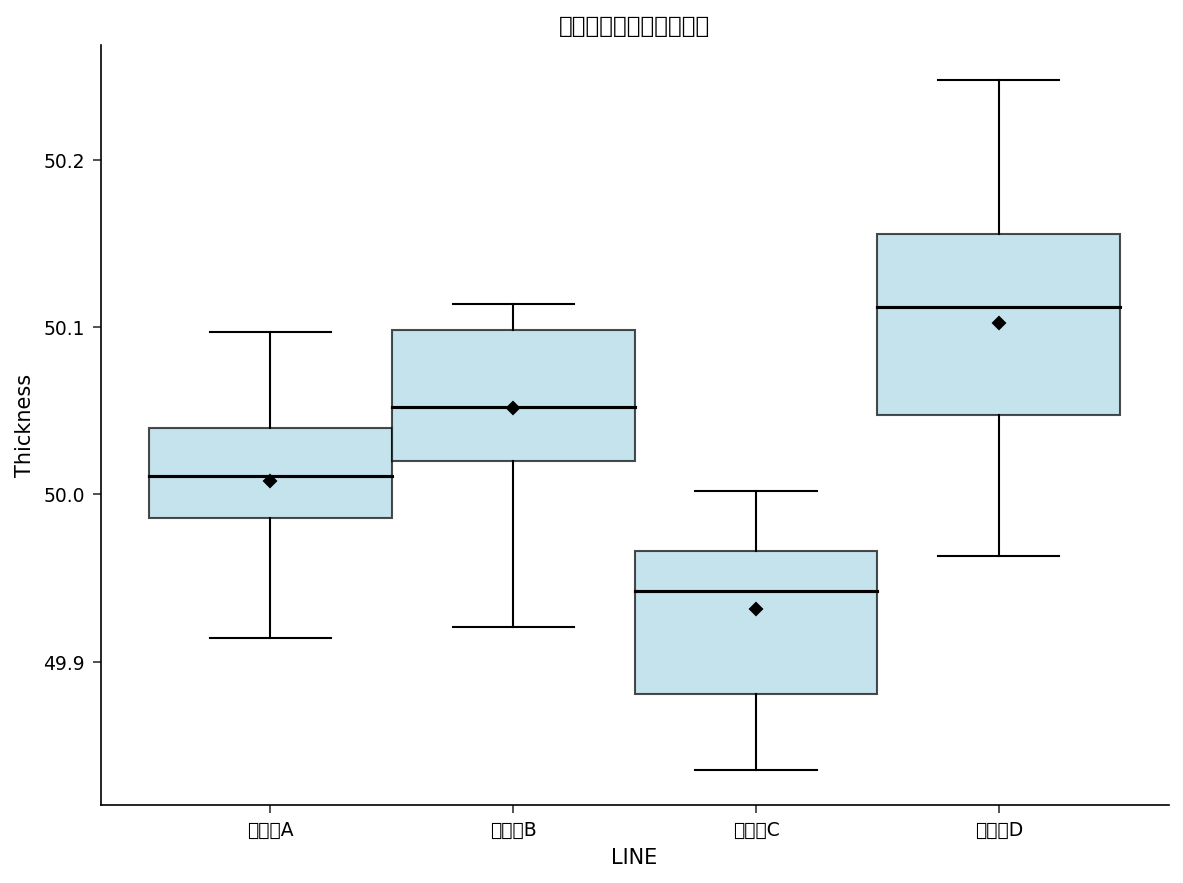

In [6]:
标题 '导出子组历史';
过程 boxplot 数据=ProcessMeas;
   PLOT Thickness*Line / outhistory=LineHistory;
运行;

标题 '汇总历史数据集（每条线一行）';
过程 打印 数据=LineHistory noobs;
运行;

标题 '据汇总历史重建的箱线图';
过程 boxplot history=LineHistory;
   PLOT Thickness*Line;
运行;

## 结果解读

将箱线图与 `PROC MEANS` 剖析、`OUTBOX=` 表以及规格界限评估一起阅读：

- **中心。** `LINE-A` 的中心最接近 50.00 mm 目标（均值 50.008 mm，中位数 50.011 mm）。`LINE-B` 略偏高（均值 50.052 mm）。`LINE-C` 偏低（均值 49.932 mm，中位数 49.942 mm），向 LSL 漂移。`LINE-D` 偏高（均值 50.102 mm，中位数 50.112 mm），是最接近 USL 的线。
- **离散度。** `LINE-D` 呈现最宽的箱体和最长的须——其标准差 0.080 mm 大约比其他三条线（0.045–0.051 mm）大 60–80%，标志其为最不稳定的线，也是变异削减研究的最佳候选。`LINE-A` 最紧凑（标准差 0.045 mm）。
- **尾部。** 在示意样式下没有任何一条线产生栅栏离群值：每条须都达到该线的真实最小/最大值，因此过程没有产出孤立的极端零件。离散度差异由每个分布的主体驱动，而非零散的点。
- **规格符合性。** 将 `OUTBOX=` 须端点据 49.80 / 50.20 mm 评估，`LINE-A`、`LINE-B` 和 `LINE-C` 完全 **符合规格**。`LINE-D` 是例外：其上须达到 **50.248 mm**，超过 **50.20 mm USL**——`LINE-D` 上的高值零件超出了上规格。
- **运营化。** `OUTBOX=` 数据集为审计人员提供图像背后精确的四分位数、须端点、均值和标准差，`OUTHISTORY=` 提供紧凑、可重绘的每线一行汇总（步骤 6），从而无需保留原始测量即可按计划重新生成图表——从汇总重建的箱线图与从原始数据绘制的完全相同。

**行动项：** 优先处理 `LINE-D`——既将其向目标下调重新居中，又启动变异削减研究，将其上须拉回 USL 之内；在 `LINE-C` 的低尾达到 LSL 之前将其向目标上调；`LINE-A` 和 `LINE-B` 运行状况可接受。